# Solve DS-MFG problem using Gurobi PoolSearch

In [1]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
from solve_gurobi_pool import (
    solve_gurobi_pool,
    load_gurobi_pool_results,
    create_flattened_dataframe,
    print_run_info,
    group_by_objective,
    print_solution_analysis,
    aggregate_pool_run_timings,
    plot_pool_replicates_ci,
)

In [2]:
# Build and solve the model using Gurobi's PoolSearch feature

# Set up paths
script_dir = Path().parent
result_dir = script_dir / "result_gurobi"


In [ ]:
# Solve with pool search
result_dict = solve_gurobi_pool(
    pool_search_mode=2,
    pool_solutions=30,
    verbose=True,
    save=True
)

In [ ]:
result_dir = script_dir / "result_gurobi" / "replicates"
n = [5, 10, 20, 30, 36, 40, 50, 80]

for num_solutions in n:
    for replicate in range(5):
        result_dict = solve_gurobi_pool(
            pool_search_mode=2,
            pool_solutions=num_solutions,
            output_dir=result_dir,
            verbose=False,
            save=True
            )

Set parameter Username
Academic license - for non-commercial use only - expires 2026-03-21
Read LP format model from file /tmp/tmpydmydk1t.lp
Reading time = 0.01 seconds
capex: 20 rows, 19 columns, 58 nonzeros
Set parameter PoolSearchMode to value 2
Set parameter PoolSolutions to value 5
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (linux64 - "Ubuntu 22.04.3 LTS")

CPU model: 13th Gen Intel(R) Core(TM) i7-1365U, instruction set [SSE2|AVX|AVX2]
Thread count: 6 physical cores, 12 logical processors, using up to 12 threads

Non-default parameters:
PoolSolutions  5
PoolSearchMode  2

Optimize a model with 20 rows, 19 columns and 58 nonzeros
Model fingerprint: 0x17eef36d
Variable types: 0 continuous, 19 integer (19 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [3e-02, 1e+01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 2e+00]
Found heuristic solution: objective 22.9099000
Presolve removed 14 rows and 9 columns
Presolve time: 0.01s
P

# Import Gurobi PoolSearch Run for Analysis

In [3]:
# Load data
import_dir = './result_gurobi'

# Update this path to your desired result file
gpool_path = os.path.join(import_dir, 'gurobi_pool_solutions_n100_20260126_105949.json')
gpool_data = load_gurobi_pool_results(gpool_path)
run_info = gpool_data['run_info']
solutions = gpool_data['solutions']

# Print run info
print(f"Loaded {len(solutions)} solutions\n")
print_run_info(run_info)

# Create flattened DataFrame
gpool_flat = create_flattened_dataframe(solutions)

# Group by objective value
obj_groups = group_by_objective(gpool_flat)
print(f"Number of unique objective values: {len(obj_groups)}")

# Analyze solutions to distinguish duplicates vs same objective
print_solution_analysis(gpool_flat)

Loaded 36 solutions

Run Info:
  Model: capex
  Variables: 19
  Constraints: 20
  Solve Time: 0.01 seconds
  Solutions Found: 36
Number of unique objective values: 36

SOLUTION ANALYSIS

1. DUPLICATE SOLUTIONS (same variable values AND same objective):
   Total solutions with duplicate variable combinations: 0
   Unique variable combinations: 36
   No true duplicate solutions found

2. SAME OBJECTIVE, DIFFERENT VARIABLES:
   Objective values with multiple variable combinations: 0

3. UNIQUE SOLUTIONS (unique in both objective and variables):
   Count: 36


{'analysis': {'duplicate_solutions': {},
  'same_obj_different_vars': {},
  'unique_solutions': [{'solution_id': 15,
    'obj_value': 16.63,
    'variable_signature': (0.0,
     0.0,
     1.0,
     0.0,
     0.0,
     0.0,
     1.0,
     1.0,
     0.0,
     0.0,
     0.0,
     1.0,
     0.0,
     1.0,
     1.0,
     1.0,
     1.0,
     0.0,
     1.0)},
   {'solution_id': 3,
    'obj_value': 12.24,
    'variable_signature': (0.0,
     0.0,
     1.0,
     0.0,
     0.0,
     0.0,
     1.0,
     1.0,
     0.0,
     0.0,
     1.0,
     0.0,
     1.0,
     1.0,
     1.0,
     1.0,
     1.0,
     1.0,
     1.0)},
   {'solution_id': 2,
    'obj_value': 11.81,
    'variable_signature': (0.0,
     0.0,
     1.0,
     0.0,
     0.0,
     0.0,
     1.0,
     1.0,
     0.0,
     1.0,
     0.0,
     0.0,
     1.0,
     1.0,
     1.0,
     1.0,
     1.0,
     1.0,
     1.0)},
   {'solution_id': 1,
    'obj_value': 11.71,
    'variable_signature': (0.0,
     0.0,
     1.0,
     -0.0,
     -0.0,
     

### Plot (# Solutions Found) vs (# PoolSearch Solution Count Setpoint)

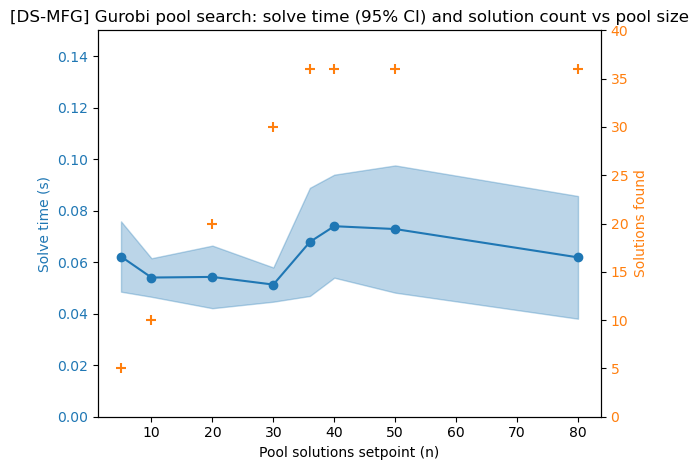

In [6]:
# Replicate plot: solve time with 95% CI, solution count on secondary axis
result_dir = script_dir / "result_gurobi" / "replicates"

plot_pool_replicates_ci(result_dir)